# Election Bloc Change Prediction Project
## Notebook 04 — Leakage-safe feature engineering

**Final full-history version: K16–K25**

### Purpose

Notebook 03 showed that **persistence remains the strongest transparent temporal baseline**. Notebook 04 therefore does not train or select a predictive model. It prepares controlled feature sets that Notebook 05 can compare fairly against persistence.

### Main methodological decisions

1. **No locality identity as a default predictor**
   - `locality_symbol` and locality name remain identifiers only.
   - locality-type variables and stable population-composition variables are isolated in sensitivity/diagnostic feature sets.

2. **Strict temporal availability**
   - a transition may use only socioeconomic snapshots available by its feature cutoff;
   - normally the cutoff is the previous-election year;
   - for two elections held in the same calendar year, the cutoff is the previous year, preventing annual data from the election year from leaking into the second election.

3. **Dynamic features are the primary challenger**
   - annualized socioeconomic and demographic changes are separated from static levels;
   - this directly tests whether change adds signal beyond election persistence.

4. **Target-blind feature filtering**
   - features are retained using development-period coverage and variance only;
   - no target correlations, feature importances, or final-test values are used for selection.

5. **The final test remains locked**
   - `K24_to_K25` is transformed with the same feature registry;
   - it is never used to choose columns or thresholds.

### Main outputs

- `data/interim/model_feature_table.csv`
- `reports/tables/notebook_04_source_inventory.csv`
- `reports/tables/notebook_04_source_schema_audit.csv`
- `reports/tables/notebook_04_feature_dictionary.csv`
- `reports/tables/notebook_04_feature_set_manifest.csv`
- `reports/tables/notebook_04_feature_coverage_by_transition.csv`
- `reports/tables/notebook_04_quality_checks.csv`
- `reports/summaries/notebook_04_summary.json`

## 0. Fresh repository checkout and environment

In [ ]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
import importlib.util
import json
import re
import shutil
import subprocess
import time
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if importlib.util.find_spec('openpyxl') is None:
    subprocess.run(
        ['pip', 'install', '-q', 'openpyxl'],
        check=True,
    )

pd.set_option('display.max_columns', 260)
pd.set_option('display.width', 380)
pd.set_option('display.max_rows', 220)

REPO_URL = 'https://github.com/IfatDav/Election_Bloc_Prediction_Project.git'
REPO_ROOT = Path('/content/Election_Bloc_Prediction_Project_nb04')

# Always clone into a new folder so stale Colab files cannot be reused.
if REPO_ROOT.exists():
    shutil.rmtree(REPO_ROOT)

subprocess.run(
    [
        'git',
        'clone',
        '--depth',
        '1',
        REPO_URL,
        str(REPO_ROOT),
    ],
    check=True,
)

GIT_COMMIT = subprocess.check_output(
    [
        'git',
        '-C',
        str(REPO_ROOT),
        'rev-parse',
        'HEAD',
    ],
    text=True,
).strip()

RAW_DIR = REPO_ROOT / 'data' / 'raw'
INTERIM_DIR = REPO_ROOT / 'data' / 'interim'
TABLES_DIR = REPO_ROOT / 'reports' / 'tables'
FIGURES_DIR = REPO_ROOT / 'reports' / 'figures'
SUMMARIES_DIR = REPO_ROOT / 'reports' / 'summaries'

for directory in [
    INTERIM_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    SUMMARIES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

MODELED_BLOCS = [
    'Right',
    'Center_Left',
    'Haredi',
    'Arab',
]

EXPECTED_TRANSITIONS = [
    f'K{number}_to_K{number + 1}'
    for number in range(16, 25)
]

DEVELOPMENT_TRANSITIONS = EXPECTED_TRANSITIONS[:-1]
FINAL_TEST_TRANSITION = EXPECTED_TRANSITIONS[-1]
ARAB_MAJORITY_THRESHOLD_PCT = 50.0

PANEL_PATH = INTERIM_DIR / 'election_transition_panel.csv'
NB02_SUMMARY_PATH = SUMMARIES_DIR / 'notebook_02_summary.json'
NB02_QUALITY_PATH = TABLES_DIR / 'transition_panel_quality_checks.csv'
NB03_SUMMARY_PATH = SUMMARIES_DIR / 'notebook_03_summary.json'
NB03_QUALITY_PATH = TABLES_DIR / 'notebook_03_quality_checks.csv'
NB03_BASELINE_PATH = TABLES_DIR / 'notebook_03_baseline_overall_summary.csv'

required_inputs = [
    PANEL_PATH,
    NB02_SUMMARY_PATH,
    NB02_QUALITY_PATH,
    NB03_SUMMARY_PATH,
    NB03_QUALITY_PATH,
    NB03_BASELINE_PATH,
]

missing_inputs = [
    str(path.relative_to(REPO_ROOT))
    for path in required_inputs
    if not path.exists()
]

if missing_inputs:
    raise FileNotFoundError(
        'Required earlier-notebook outputs are missing from GitHub:\n- '
        + '\n- '.join(missing_inputs)
    )

print('Fresh repository:', REPO_ROOT)
print('Git commit:', GIT_COMMIT)

Fresh repository: /content/Election_Bloc_Prediction_Project_nb04
Git commit: 28438c15d82919bb89b7a1838e33e7699812103e


## 1. Validate Notebook 02 and Notebook 03 outputs

In [ ]:
def parse_boolean_series(series):
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .isin(['true', '1', 'yes'])
    )


with NB02_SUMMARY_PATH.open('r', encoding='utf-8') as file:
    nb02_summary = json.load(file)

with NB03_SUMMARY_PATH.open('r', encoding='utf-8') as file:
    nb03_summary = json.load(file)

nb02_quality = pd.read_csv(
    NB02_QUALITY_PATH,
    encoding='utf-8-sig',
)

nb03_quality = pd.read_csv(
    NB03_QUALITY_PATH,
    encoding='utf-8-sig',
)

nb03_baseline_summary = pd.read_csv(
    NB03_BASELINE_PATH,
    encoding='utf-8-sig',
)

nb02_quality['passed'] = parse_boolean_series(
    nb02_quality['passed']
)

nb03_quality['passed'] = parse_boolean_series(
    nb03_quality['passed']
)

if not nb02_quality['passed'].all():
    raise RuntimeError(
        'Notebook 02 quality checks are not all successful.'
    )

if not nb03_quality['passed'].all():
    raise RuntimeError(
        'Notebook 03 quality checks are not all successful.'
    )

if nb02_summary.get('version') != 'full_history_K16_K25':
    raise ValueError(
        'Notebook 02 is not the full-history K16–K25 version.'
    )

if nb02_summary.get('transitions') != EXPECTED_TRANSITIONS:
    raise ValueError(
        'Notebook 02 summary does not contain all nine transitions.'
    )

if nb03_summary.get('development_transitions') != DEVELOPMENT_TRANSITIONS:
    raise ValueError(
        'Notebook 03 development transitions do not match the frozen policy.'
    )

if nb03_summary.get('final_test_transition') != FINAL_TEST_TRANSITION:
    raise ValueError(
        'Notebook 03 identifies the wrong final-test transition.'
    )

if not bool(nb03_summary.get('final_test_locked')):
    raise ValueError('Notebook 03 final test is not locked.')

best_baseline_name = str(
    nb03_summary.get('best_transparent_baseline')
)

if best_baseline_name != 'Persistence':
    raise ValueError(
        'Notebook 04 expects the frozen Notebook 03 conclusion '
        'that Persistence is the best transparent baseline. '
        f'Found: {best_baseline_name}'
    )

print('Earlier-notebook validation passed.')
print('Notebook 02 panel rows:', nb02_summary['panel_rows'])
print('Notebook 03 best transparent baseline:', best_baseline_name)
print('Notebook 03 mean-fold persistence MAE:', nb03_summary['persistence_mean_fold_mae'])

display(nb03_baseline_summary)

Earlier-notebook validation passed.
Notebook 02 panel rows: 10658
Notebook 03 best transparent baseline: Persistence
Notebook 03 mean-fold persistence MAE: 3.2477548482871015


,model,rows,overall_mae,weighted_mae,median_row_mae,p90_row_mae,maximum_row_error,Right_mae,Center_Left_mae,Haredi_mae,Arab_mae,mean_fold_mae,median_fold_mae,standard_deviation_fold_mae,worst_fold_mae,best_fold_mae
0,Persistence,6012.0,3.240424,2.802978,2.252344,6.753407,62.608696,5.015981,4.213415,2.192492,1.539808,3.247755,3.083028,0.969150,4.826111,2.159375
1,Expanding median CLR shift,6012.0,3.629509,3.564225,2.636270,7.229403,62.852352,5.692383,4.667595,2.586198,1.571862,3.637758,3.441124,0.962883,4.868484,2.492141
2,Expanding mean CLR shift,6012.0,3.991979,4.090426,2.757954,8.543253,66.792570,6.430287,4.356991,3.526360,1.654277,4.006392,2.963628,2.073721,7.645059,2.795110
3,Locality historical mean CLR shift,6012.0,6.154559,3.450829,3.221486,14.241107,99.995484,7.293750,7.916276,5.306248,4.101961,6.184017,4.525719,3.785033,12.896230,3.819348
4,Last-transition mean CLR shift,6012.0,6.574679,8.493752,4.076977,15.962722,85.694931,8.769254,6.543853,8.478672,2.506936,6.612788,5.639764,4.803165,14.800091,2.659020


## 2. Load and validate the transition panel

In [ ]:
def normalize_locality_symbol(series):
    normalized = series.astype('string').str.strip()
    normalized = normalized.str.replace(
        r'\.0+$',
        '',
        regex=True,
    )
    return normalized.replace(
        {
            '': pd.NA,
            'nan': pd.NA,
            'None': pd.NA,
            '<NA>': pd.NA,
        }
    )


panel = pd.read_csv(
    PANEL_PATH,
    dtype={'locality_symbol': 'string'},
    low_memory=False,
)

panel['locality_symbol'] = normalize_locality_symbol(
    panel['locality_symbol']
)

required_panel_columns = {
    'locality_symbol',
    'locality_name',
    'transition_id',
    'transition_order',
    'final_test_locked',
    'data_role',
    'previous_election_number',
    'current_election_number',
    'previous_year',
    'current_year',
    'year_gap',
    'previous_valid_votes',
    'current_valid_votes',
    'previous_turnout_pct',
    'previous_Other_raw_pct',
    'previous_modeled_vote_coverage_pct',
    *[
        f'previous_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'current_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'delta_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'previous_clr_{bloc}'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'delta_clr_{bloc}'
        for bloc in MODELED_BLOCS
    ],
}

missing_panel_columns = sorted(
    required_panel_columns - set(panel.columns)
)

if missing_panel_columns:
    raise KeyError(
        'Transition panel is missing required columns:\n- '
        + '\n- '.join(missing_panel_columns)
    )

numeric_panel_columns = [
    'transition_order',
    'previous_election_number',
    'current_election_number',
    'previous_year',
    'current_year',
    'year_gap',
    'previous_valid_votes',
    'current_valid_votes',
    'previous_turnout_pct',
    'previous_Other_raw_pct',
    'previous_modeled_vote_coverage_pct',
    *[
        f'previous_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'current_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'delta_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'previous_clr_{bloc}'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'delta_clr_{bloc}'
        for bloc in MODELED_BLOCS
    ],
]

for column in numeric_panel_columns:
    panel[column] = pd.to_numeric(
        panel[column],
        errors='coerce',
    ).astype('float64')

panel['final_test_locked'] = parse_boolean_series(
    panel['final_test_locked']
)

actual_transitions = (
    panel[
        ['transition_id', 'transition_order']
    ]
    .drop_duplicates()
    .sort_values('transition_order')['transition_id']
    .tolist()
)

if actual_transitions != EXPECTED_TRANSITIONS:
    raise ValueError(
        'Transition panel is incomplete or incorrectly ordered.\n'
        f'Expected: {EXPECTED_TRANSITIONS}\n'
        f'Found: {actual_transitions}'
    )

if int(panel.duplicated(['transition_id', 'locality_symbol']).sum()):
    raise ValueError('Duplicate locality-transition rows were found.')

locked_transitions = (
    panel.loc[
        panel['final_test_locked'],
        'transition_id',
    ]
    .drop_duplicates()
    .tolist()
)

if locked_transitions != [FINAL_TEST_TRANSITION]:
    raise ValueError(
        'Only K24_to_K25 may be locked. '
        f'Found: {locked_transitions}'
    )

# Timing policy:
# - normally use data available by the previous-election year;
# - for two elections in the same year, use the preceding calendar year.
panel['feature_cutoff_year'] = np.where(
    panel['current_year'].eq(panel['previous_year']),
    panel['previous_year'] - 1,
    panel['previous_year'],
).astype('int64')

panel['row_id'] = np.arange(len(panel), dtype='int64')

panel_symbols = set(
    panel['locality_symbol']
    .dropna()
    .astype(str)
)

print('Transition panel validation passed.')
print('Rows:', len(panel))
print('Unique localities:', panel['locality_symbol'].nunique())
print('Feature cutoff years:', sorted(panel['feature_cutoff_year'].unique().tolist()))

Transition panel validation passed.
Rows: 10658
Unique localities: 1226
Feature cutoff years: [2003, 2006, 2009, 2013, 2015, 2018, 2019, 2020, 2021]


## 3. Define and audit all socioeconomic source files

In [ ]:
SOURCE_YEARS = {
    'demographic': [
        2003, 2006, 2009, 2013, 2015,
        2019, 2020, 2021, 2022, 2023,
    ],
    'income': [
        2003, 2006, 2009, 2013, 2015,
        2019, 2020, 2021, 2022, 2023,
    ],
    'unemployment': [
        2003, 2006, 2009, 2013, 2015,
        2019, 2020, 2021, 2022, 2023,
    ],
    'education': [
        2016, 2019, 2020, 2021, 2022, 2023,
    ],
}

SOURCE_TEMPLATES = {
    'demographic': (
        RAW_DIR / 'Demographic_data' / 'Demographic_{year}.xlsx'
    ),
    'income': (
        RAW_DIR / 'Average_income' / 'ICBS_{year}.xlsx'
    ),
    'unemployment': (
        RAW_DIR / 'Unemployment_data' / 'Unemployment_{year}.xlsx'
    ),
    'education': (
        RAW_DIR / 'Education_data' / 'Education_{year}.xlsx'
    ),
}

source_rows = []

for family, years in SOURCE_YEARS.items():
    template = str(SOURCE_TEMPLATES[family])

    for year in years:
        path = Path(template.format(year=year))

        source_rows.append({
            'family': family,
            'source_year': year,
            'relative_path': str(path.relative_to(REPO_ROOT)),
            'exists': path.exists(),
            'size_bytes': (
                path.stat().st_size
                if path.exists()
                else 0
            ),
        })

LOCALITY_TYPE_PATH = RAW_DIR / 'Locality_Types.xlsx'

source_rows.append({
    'family': 'locality_type',
    'source_year': pd.NA,
    'relative_path': str(LOCALITY_TYPE_PATH.relative_to(REPO_ROOT)),
    'exists': LOCALITY_TYPE_PATH.exists(),
    'size_bytes': (
        LOCALITY_TYPE_PATH.stat().st_size
        if LOCALITY_TYPE_PATH.exists()
        else 0
    ),
})

source_inventory = pd.DataFrame(source_rows)

missing_source_files = source_inventory.loc[
    ~source_inventory['exists']
    | source_inventory['size_bytes'].le(0)
]

if not missing_source_files.empty:
    raise FileNotFoundError(
        'Expected socioeconomic source files are missing or empty:\n'
        + missing_source_files.to_string(index=False)
    )

print('Expected socioeconomic files:', len(source_inventory))
print('Time-varying files:', int(source_inventory['source_year'].notna().sum()))
print('Static locality files:', int(source_inventory['source_year'].isna().sum()))

display(source_inventory)

Expected socioeconomic files: 37
Time-varying files: 36
Static locality files: 1


,family,source_year,relative_path,exists,size_bytes
0,demographic,2003,data/raw/Demographic_data/Demographic_2003.xlsx,True,48625
1,demographic,2006,data/raw/Demographic_data/Demographic_2006.xlsx,True,49636
2,demographic,2009,data/raw/Demographic_data/Demographic_2009.xlsx,True,47682
3,demographic,2013,data/raw/Demographic_data/Demographic_2013.xlsx,True,50870
4,demographic,2015,data/raw/Demographic_data/Demographic_2015.xlsx,True,48385
5,demographic,2019,data/raw/Demographic_data/Demographic_2019.xlsx,True,81004
6,demographic,2020,data/raw/Demographic_data/Demographic_2020.xlsx,True,88343
7,demographic,2021,data/raw/Demographic_data/Demographic_2021.xlsx,True,88556
8,demographic,2022,data/raw/Demographic_data/Demographic_2022.xlsx,True,82389
9,demographic,2023,data/raw/Demographic_data/Demographic_2023.xlsx,True,81007


## 4. Robust Excel schema detection and numeric extraction

In [ ]:
def normalize_text(value):
    if value is None or pd.isna(value):
        return ''

    text = unicodedata.normalize(
        'NFKC',
        str(value),
    )

    text = text.replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text


def normalize_column_slug(value):
    text = normalize_text(value)
    text = text.replace('%', ' אחוז ')
    text = re.sub(
        r'[^0-9a-zA-Z_\u0590-\u05FF]+',
        '_',
        text,
    )
    text = re.sub(r'_+', '_', text).strip('_')
    return text or 'unnamed_feature'


def coerce_numeric(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce')

    cleaned = (
        series.astype('string')
        .str.strip()
        .str.replace(',', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.replace('−', '-', regex=False)
        .str.replace('–', '-', regex=False)
        .str.replace(r'^[<>]=?\s*', '', regex=True)
        .replace({
            '': pd.NA,
            '..': pd.NA,
            '...': pd.NA,
            '-': pd.NA,
            '—': pd.NA,
            'na': pd.NA,
            'n/a': pd.NA,
            'nan': pd.NA,
        })
    )

    return pd.to_numeric(cleaned, errors='coerce')


SYMBOL_ALIASES = {
    normalize_text(value)
    for value in [
        'locality_symbol',
        'locality code',
        'locality_code',
        'semel yishuv',
        'semel_yeshuv',
        'סמל יישוב',
        'סמל ישוב',
        'סמל היישוב',
        'סמל הישוב',
        'סמל',
    ]
}

NAME_ALIASES = {
    normalize_text(value)
    for value in [
        'locality_name',
        'locality name',
        'name of locality',
        'שם יישוב',
        'שם ישוב',
        'שם היישוב',
        'שם הישוב',
    ]
}


def symbol_column_score(series, column_name, known_symbols):
    normalized_name = normalize_text(column_name)

    alias_bonus = 0.0

    if normalized_name in SYMBOL_ALIASES:
        alias_bonus = 20.0
    elif (
        ('סמל' in normalized_name and ('ישוב' in normalized_name or 'יישוב' in normalized_name))
        or ('locality' in normalized_name and ('symbol' in normalized_name or 'code' in normalized_name))
        or ('semel' in normalized_name)
    ):
        alias_bonus = 12.0

    numeric = coerce_numeric(series)
    nonmissing = numeric.dropna()

    if nonmissing.empty:
        return -np.inf

    integer_like = nonmissing.loc[
        np.isclose(nonmissing % 1, 0)
        & nonmissing.between(1, 99999)
    ]

    if integer_like.empty:
        return -np.inf

    candidate_symbols = set(
        integer_like.astype('Int64').astype('string')
    )

    overlap_count = len(candidate_symbols & known_symbols)
    overlap_ratio = (
        overlap_count / max(len(candidate_symbols), 1)
    )

    coverage = len(integer_like) / max(len(series), 1)

    return (
        alias_bonus
        + overlap_ratio * 20.0
        + min(overlap_count, 1000) / 1000.0
        + coverage
    )


def detect_symbol_column(df, known_symbols):
    scores = {
        column: symbol_column_score(
            df[column],
            column,
            known_symbols,
        )
        for column in df.columns
    }

    best_column = max(scores, key=scores.get)
    best_score = scores[best_column]

    if not np.isfinite(best_score) or best_score < 3.0:
        return None, best_score

    return best_column, best_score


def detect_name_column(df):
    for column in df.columns:
        normalized = normalize_text(column)

        if normalized in NAME_ALIASES:
            return column

    for column in df.columns:
        normalized = normalize_text(column)

        if (
            ('שם' in normalized and ('ישוב' in normalized or 'יישוב' in normalized))
            or ('locality' in normalized and 'name' in normalized)
        ):
            return column

    return None


def read_excel_with_detected_header(path, known_symbols, max_header_row=12):
    try:
        raw_matrix = pd.read_excel(
            path,
            sheet_name=0,
            header=None,
            engine='openpyxl',
        )
    except Exception as error:
        raise RuntimeError(
            f'Could not read Excel source {path}: {error}'
        ) from error

    raw_matrix = raw_matrix.dropna(axis=0, how='all').dropna(
        axis=1,
        how='all',
    )

    if raw_matrix.empty:
        raise ValueError(f'Excel source is empty: {path}')

    def unique_header_labels(values):
        counts = {}
        labels = []

        for position, value in enumerate(values):
            if value is None or pd.isna(value):
                base = f'Unnamed_{position}'
            else:
                base = str(value).strip()
                if not base:
                    base = f'Unnamed_{position}'

            counts[base] = counts.get(base, 0) + 1

            if counts[base] == 1:
                label = base
            else:
                label = f'{base}__{counts[base]}'

            labels.append(label)

        return labels

    trial_rows = []
    successful_trials = []
    last_header_row = min(max_header_row, len(raw_matrix) - 2)

    for header_row in range(last_header_row + 1):
        labels = unique_header_labels(
            raw_matrix.iloc[header_row].tolist()
        )

        trial = raw_matrix.iloc[header_row + 1:].copy()
        trial.columns = labels
        trial = trial.reset_index(drop=True)
        trial = trial.dropna(axis=0, how='all').dropna(axis=1, how='all')

        symbol_column, symbol_score = detect_symbol_column(
            trial,
            known_symbols,
        )

        numeric_candidate_count = 0

        for column in trial.columns:
            values = coerce_numeric(trial[column])
            original_nonmissing = int(trial[column].notna().sum())

            if original_nonmissing == 0:
                continue

            numeric_fraction = (
                values.notna().sum()
                / original_nonmissing
            )

            if numeric_fraction >= 0.50:
                numeric_candidate_count += 1

        score = (
            (symbol_score if np.isfinite(symbol_score) else -100.0)
            + numeric_candidate_count * 0.05
            - header_row * 0.001
        )

        trial_rows.append({
            'header_row': header_row,
            'read_success': True,
            'symbol_column': (
                str(symbol_column)
                if symbol_column is not None
                else None
            ),
            'symbol_score': symbol_score,
            'numeric_candidate_columns': numeric_candidate_count,
            'columns': trial.shape[1],
            'rows': trial.shape[0],
            'error': None,
            'overall_score': score,
        })

        if symbol_column is not None:
            successful_trials.append(
                (score, header_row, trial, symbol_column)
            )

    if not successful_trials:
        raise ValueError(
            f'Could not identify a locality-symbol column in {path}'
        )

    successful_trials.sort(
        key=lambda item: item[0],
        reverse=True,
    )

    _, selected_header_row, selected_df, symbol_column = (
        successful_trials[0]
    )

    selected_df = (
        selected_df
        .dropna(axis=0, how='all')
        .dropna(axis=1, how='all')
        .copy()
    )

    return (
        selected_df,
        symbol_column,
        detect_name_column(selected_df),
        selected_header_row,
        pd.DataFrame(trial_rows),
    )


## 5. Read and standardize all time-varying source tables

In [ ]:
def deduplicate_slugs(original_columns):
    counts = {}
    mapping = {}

    for column in original_columns:
        base_slug = normalize_column_slug(column)
        counts[base_slug] = counts.get(base_slug, 0) + 1

        if counts[base_slug] == 1:
            slug = base_slug
        else:
            slug = f'{base_slug}__{counts[base_slug]}'

        mapping[column] = slug

    return mapping


def standardize_time_varying_source(
    path,
    family,
    source_year,
    known_symbols,
):
    (
        raw,
        symbol_column,
        name_column,
        header_row,
        header_trials,
    ) = read_excel_with_detected_header(
        path,
        known_symbols,
    )

    raw_rows = len(raw)

    standardized = pd.DataFrame({
        'locality_symbol': normalize_locality_symbol(
            coerce_numeric(raw[symbol_column]).astype('Int64')
        ),
        'snapshot_year': int(source_year),
    })

    standardized['locality_name_source'] = (
        raw[name_column].astype('string').str.strip()
        if name_column is not None
        else pd.Series(pd.NA, index=raw.index, dtype='string')
    )

    excluded_columns = {
        symbol_column,
    }

    if name_column is not None:
        excluded_columns.add(name_column)

    candidate_columns = [
        column
        for column in raw.columns
        if column not in excluded_columns
        and not normalize_text(column).startswith('unnamed')
    ]

    slug_mapping = deduplicate_slugs(candidate_columns)

    feature_dictionary_rows = []
    retained_feature_columns = []

    for column in candidate_columns:
        numeric = coerce_numeric(raw[column])
        original_nonmissing = int(raw[column].notna().sum())
        numeric_nonmissing = int(numeric.notna().sum())

        numeric_fraction = (
            numeric_nonmissing / original_nonmissing
            if original_nonmissing > 0
            else 0.0
        )

        if numeric_nonmissing < 5 or numeric_fraction < 0.50:
            continue

        feature_name = (
            f'{family}__{slug_mapping[column]}'
        )

        standardized[feature_name] = numeric.astype('float64')
        retained_feature_columns.append(feature_name)

        feature_dictionary_rows.append({
            'source_family': family,
            'source_year': source_year,
            'relative_path': str(path.relative_to(REPO_ROOT)),
            'original_column': str(column),
            'canonical_source_feature': feature_name,
            'numeric_fraction': numeric_fraction,
            'nonmissing_values': numeric_nonmissing,
        })

    standardized = standardized.loc[
        standardized['locality_symbol'].isin(known_symbols)
    ].copy()

    duplicate_rows = int(
        standardized.duplicated(
            ['locality_symbol', 'snapshot_year']
        ).sum()
    )

    if duplicate_rows:
        numeric_feature_columns = [
            column
            for column in retained_feature_columns
            if column in standardized.columns
        ]

        name_table = (
            standardized
            .groupby(
                ['locality_symbol', 'snapshot_year'],
                as_index=False,
            )['locality_name_source']
            .first()
        )

        numeric_table = (
            standardized
            .groupby(
                ['locality_symbol', 'snapshot_year'],
                as_index=False,
            )[numeric_feature_columns]
            .mean()
        )

        standardized = name_table.merge(
            numeric_table,
            on=['locality_symbol', 'snapshot_year'],
            how='outer',
            validate='one_to_one',
        )

    schema_audit = {
        'family': family,
        'source_year': source_year,
        'relative_path': str(path.relative_to(REPO_ROOT)),
        'header_row_zero_based': header_row,
        'symbol_column': str(symbol_column),
        'name_column': (
            str(name_column)
            if name_column is not None
            else None
        ),
        'raw_rows': raw_rows,
        'matched_locality_rows': len(standardized),
        'unique_localities': standardized['locality_symbol'].nunique(),
        'duplicate_rows_before_aggregation': duplicate_rows,
        'retained_numeric_features': len(retained_feature_columns),
        'header_trial_count': len(header_trials),
    }

    return (
        standardized,
        schema_audit,
        feature_dictionary_rows,
    )


source_frames = []
schema_audit_rows = []
source_feature_dictionary_rows = []

for source in source_inventory.loc[
    source_inventory['source_year'].notna()
].itertuples(index=False):
    path = REPO_ROOT / source.relative_path

    (
        standardized_source,
        schema_audit,
        dictionary_rows,
    ) = standardize_time_varying_source(
        path=path,
        family=source.family,
        source_year=int(source.source_year),
        known_symbols=panel_symbols,
    )

    source_frames.append(standardized_source)
    schema_audit_rows.append(schema_audit)
    source_feature_dictionary_rows.extend(dictionary_rows)

    print(
        f"{source.family} {int(source.source_year)}: "
        f"{schema_audit['unique_localities']} localities, "
        f"{schema_audit['retained_numeric_features']} numeric features"
    )

source_schema_audit = pd.DataFrame(schema_audit_rows)
source_feature_dictionary_raw = pd.DataFrame(
    source_feature_dictionary_rows
)

display(source_schema_audit)

demographic 2003: 202 localities, 26 numeric features
demographic 2006: 197 localities, 27 numeric features
demographic 2009: 200 localities, 27 numeric features
demographic 2013: 201 localities, 27 numeric features
demographic 2015: 201 localities, 27 numeric features
demographic 2019: 192 localities, 57 numeric features
demographic 2020: 201 localities, 53 numeric features
demographic 2021: 201 localities, 53 numeric features
demographic 2022: 201 localities, 53 numeric features
demographic 2023: 192 localities, 57 numeric features
income 2003: 222 localities, 13 numeric features
income 2006: 221 localities, 13 numeric features
income 2009: 223 localities, 13 numeric features
income 2013: 224 localities, 13 numeric features
income 2015: 224 localities, 13 numeric features
income 2019: 224 localities, 13 numeric features
income 2020: 197 localities, 3 numeric features
income 2021: 224 localities, 13 numeric features
income 2022: 225 localities, 13 numeric features
income 2023: 199 loc

,family,source_year,relative_path,header_row_zero_based,symbol_column,name_column,raw_rows,matched_locality_rows,unique_localities,duplicate_rows_before_aggregation,retained_numeric_features,header_trial_count
0,demographic,2003,data/raw/Demographic_data/Demographic_2003.xlsx,0,סמל היישוב,שם יישוב,202,202,202,0,26,13
1,demographic,2006,data/raw/Demographic_data/Demographic_2006.xlsx,0,סמל היישוב,שם יישוב,197,197,197,0,27,13
2,demographic,2009,data/raw/Demographic_data/Demographic_2009.xlsx,0,סמל היישוב,שם יישוב,200,200,200,0,27,13
3,demographic,2013,data/raw/Demographic_data/Demographic_2013.xlsx,0,סמל היישוב,שם יישוב,201,201,201,0,27,13
4,demographic,2015,data/raw/Demographic_data/Demographic_2015.xlsx,0,סמל היישוב,שם יישוב,201,201,201,0,27,13
5,demographic,2019,data/raw/Demographic_data/Demographic_2019.xlsx,0,סמל היישוב,שם יישוב,193,192,192,0,57,13
6,demographic,2020,data/raw/Demographic_data/Demographic_2020.xlsx,0,סמל היישוב,שם יישוב,201,201,201,0,53,13
7,demographic,2021,data/raw/Demographic_data/Demographic_2021.xlsx,0,סמל היישוב,שם יישוב,201,201,201,0,53,13
8,demographic,2022,data/raw/Demographic_data/Demographic_2022.xlsx,0,סמל היישוב,שם יישוב,202,201,201,0,53,13
9,demographic,2023,data/raw/Demographic_data/Demographic_2023.xlsx,0,סמל היישוב,שם יישוב,193,192,192,0,57,13


## 6. Combine annual files into one panel per source family

In [ ]:
family_panels = {}
family_availability_rows = []

for family in SOURCE_YEARS:
    family_frames = [
        frame
        for frame, source in zip(
            source_frames,
            source_inventory.loc[
                source_inventory['source_year'].notna()
            ].itertuples(index=False),
        )
        if source.family == family
    ]

    combined = pd.concat(
        family_frames,
        ignore_index=True,
        sort=False,
    )

    feature_columns = [
        column
        for column in combined.columns
        if column.startswith(f'{family}__')
    ]

    # There is one expected source file per family-year. The aggregation
    # remains defensive in case a source contains duplicated locality rows.
    name_panel = (
        combined
        .groupby(
            ['locality_symbol', 'snapshot_year'],
            as_index=False,
        )['locality_name_source']
        .first()
    )

    numeric_panel = (
        combined
        .groupby(
            ['locality_symbol', 'snapshot_year'],
            as_index=False,
        )[feature_columns]
        .mean()
    )

    family_panel = name_panel.merge(
        numeric_panel,
        on=['locality_symbol', 'snapshot_year'],
        how='outer',
        validate='one_to_one',
    )

    family_panel = family_panel.sort_values(
        ['locality_symbol', 'snapshot_year']
    ).reset_index(drop=True)

    family_panels[family] = family_panel

    for year, year_frame in family_panel.groupby('snapshot_year'):
        family_availability_rows.append({
            'family': family,
            'snapshot_year': int(year),
            'rows': len(year_frame),
            'unique_localities': year_frame['locality_symbol'].nunique(),
            'available_numeric_features': int(
                year_frame[feature_columns]
                .notna()
                .any(axis=0)
                .sum()
            ),
        })

family_source_availability = pd.DataFrame(
    family_availability_rows
)

for family, family_panel in family_panels.items():
    print(
        family,
        'years=',
        sorted(family_panel['snapshot_year'].unique().tolist()),
        'features=',
        len([
            column
            for column in family_panel.columns
            if column.startswith(f'{family}__')
        ]),
    )

display(family_source_availability)

demographic years= [2003, 2006, 2009, 2013, 2015, 2019, 2020, 2021, 2022, 2023] features= 187
income years= [2003, 2006, 2009, 2013, 2015, 2019, 2020, 2021, 2022, 2023] features= 26
unemployment years= [2003, 2006, 2009, 2013, 2015, 2019, 2020, 2021, 2022, 2023] features= 30
education years= [2016, 2019, 2020, 2021, 2022, 2023] features= 65


,family,snapshot_year,rows,unique_localities,available_numeric_features
0,demographic,2003,202,202,26
1,demographic,2006,197,197,27
2,demographic,2009,200,200,27
3,demographic,2013,201,201,27
4,demographic,2015,201,201,27
5,demographic,2019,192,192,57
6,demographic,2020,201,201,53
7,demographic,2021,201,201,53
8,demographic,2022,201,201,53
9,demographic,2023,192,192,57


## 7. Read locality-type variables as diagnostic identity features

In [ ]:
(
    locality_type_raw,
    locality_type_symbol_column,
    locality_type_name_column,
    locality_type_header_row,
    locality_type_header_trials,
) = read_excel_with_detected_header(
    LOCALITY_TYPE_PATH,
    panel_symbols,
)

locality_type_table = pd.DataFrame({
    'locality_symbol': normalize_locality_symbol(
        coerce_numeric(
            locality_type_raw[locality_type_symbol_column]
        ).astype('Int64')
    ),
})

locality_type_excluded = {
    locality_type_symbol_column,
}

if locality_type_name_column is not None:
    locality_type_excluded.add(locality_type_name_column)

locality_type_feature_rows = []

for column in locality_type_raw.columns:
    if column in locality_type_excluded:
        continue

    normalized_name = normalize_text(column)

    if normalized_name.startswith('unnamed'):
        continue

    numeric = coerce_numeric(locality_type_raw[column])
    original_nonmissing = int(
        locality_type_raw[column].notna().sum()
    )

    numeric_fraction = (
        numeric.notna().sum() / original_nonmissing
        if original_nonmissing > 0
        else 0.0
    )

    base_slug = normalize_column_slug(column)

    if numeric_fraction >= 0.80 and numeric.notna().sum() >= 5:
        feature_name = f'locality_type__{base_slug}'
        locality_type_table[feature_name] = numeric.astype('float64')

        locality_type_feature_rows.append({
            'source_family': 'locality_type',
            'source_year': pd.NA,
            'relative_path': str(LOCALITY_TYPE_PATH.relative_to(REPO_ROOT)),
            'original_column': str(column),
            'canonical_source_feature': feature_name,
            'numeric_fraction': numeric_fraction,
            'nonmissing_values': int(numeric.notna().sum()),
        })
        continue

    categorical = (
        locality_type_raw[column]
        .astype('string')
        .str.strip()
        .replace({'': pd.NA})
    )

    unique_count = int(categorical.nunique(dropna=True))

    if 2 <= unique_count <= 30:
        dummies = pd.get_dummies(
            categorical,
            prefix=f'locality_type__{base_slug}',
            prefix_sep='__',
            dummy_na=False,
            dtype='float64',
        )

        locality_type_table = pd.concat(
            [locality_type_table, dummies],
            axis=1,
        )

        for dummy_column in dummies.columns:
            locality_type_feature_rows.append({
                'source_family': 'locality_type',
                'source_year': pd.NA,
                'relative_path': str(LOCALITY_TYPE_PATH.relative_to(REPO_ROOT)),
                'original_column': str(column),
                'canonical_source_feature': dummy_column,
                'numeric_fraction': np.nan,
                'nonmissing_values': int(dummies[dummy_column].notna().sum()),
            })

locality_type_table = locality_type_table.loc[
    locality_type_table['locality_symbol'].isin(panel_symbols)
].copy()

locality_type_table = (
    locality_type_table
    .groupby('locality_symbol', as_index=False)
    .max()
)

source_feature_dictionary_raw = pd.concat(
    [
        source_feature_dictionary_raw,
        pd.DataFrame(locality_type_feature_rows),
    ],
    ignore_index=True,
    sort=False,
)

print('Locality-type header row:', locality_type_header_row)
print('Locality-type rows:', len(locality_type_table))
print(
    'Locality-type diagnostic features:',
    len(locality_type_table.columns) - 1,
)

Locality-type header row: 0
Locality-type rows: 1217
Locality-type diagnostic features: 32


## 8. Attach the latest permitted snapshot and its prior change

In [ ]:
def attach_family_features(base_rows, family, family_panel):
    family_panel = family_panel.copy()

    feature_columns = [
        column
        for column in family_panel.columns
        if column.startswith(f"{family}__")
    ]

    if not feature_columns:
        raise ValueError(
            f"No feature columns were found for family: {family}"
        )

    family_panel["snapshot_year"] = pd.to_numeric(
        family_panel["snapshot_year"],
        errors="raise",
    ).astype("int64")

    family_panel = (
        family_panel
        .sort_values(
            ["locality_symbol", "snapshot_year"],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    prior_values = (
        family_panel
        .groupby("locality_symbol", sort=False)[feature_columns]
        .shift(1)
    )

    prior_values.columns = [
        f"prior__{column}"
        for column in feature_columns
    ]

    family_panel["prior_snapshot_year"] = (
        family_panel
        .groupby("locality_symbol", sort=False)["snapshot_year"]
        .shift(1)
    )

    family_panel = pd.concat(
        [family_panel, prior_values],
        axis=1,
    ).copy()

    left = base_rows[
        [
            "row_id",
            "locality_symbol",
            "feature_cutoff_year",
        ]
    ].copy()

    left["feature_cutoff_year"] = pd.to_numeric(
        left["feature_cutoff_year"],
        errors="raise",
    ).astype("int64")

    left = left.sort_values(
        ["feature_cutoff_year", "locality_symbol"],
        kind="mergesort",
    )

    right = family_panel.sort_values(
        ["snapshot_year", "locality_symbol"],
        kind="mergesort",
    )

    merged = pd.merge_asof(
        left,
        right,
        left_on="feature_cutoff_year",
        right_on="snapshot_year",
        by="locality_symbol",
        direction="backward",
        allow_exact_matches=True,
    )

    snapshot_interval = (
        merged["snapshot_year"]
        - merged["prior_snapshot_year"]
    )

    valid_interval = snapshot_interval.where(
        snapshot_interval.gt(0)
    )

    metadata = pd.DataFrame({
        "row_id": merged["row_id"],
        f"{family}__snapshot_year": merged["snapshot_year"],
        f"{family}__snapshot_age_years": (
            merged["feature_cutoff_year"]
            - merged["snapshot_year"]
        ),
        f"{family}__snapshot_interval_years": snapshot_interval,
    })

    level_values = merged[feature_columns].copy()
    level_values.columns = [
        f"{column}__level"
        for column in feature_columns
    ]

    prior_columns = [
        f"prior__{column}"
        for column in feature_columns
    ]

    prior_matrix = merged[prior_columns].copy()
    prior_matrix.columns = feature_columns

    change_values = (
        merged[feature_columns]
        .sub(prior_matrix)
        .div(valid_interval, axis=0)
    )

    change_values.columns = [
        f"{column}__annualized_change"
        for column in feature_columns
    ]

    output = pd.concat(
        [
            metadata,
            level_values,
            change_values,
        ],
        axis=1,
    )

    return (
        output
        .sort_values("row_id")
        .reset_index(drop=True)
        .copy()
    )


attached_family_tables = {}

for family, family_panel in family_panels.items():
    attached = attach_family_features(
        base_rows=panel,
        family=family,
        family_panel=family_panel,
    )

    attached_family_tables[family] = attached

    snapshot_column = f"{family}__snapshot_year"

    available_snapshot_rows = int(
        attached[snapshot_column].notna().sum()
    )

    print(
        family,
        "attached rows with a permitted snapshot:",
        available_snapshot_rows,
        "/",
        len(attached),
    )

demographic attached rows with a permitted snapshot: 1843 / 10658
income attached rows with a permitted snapshot: 2023 / 10658
unemployment attached rows with a permitted snapshot: 2049 / 10658
education attached rows with a permitted snapshot: 804 / 10658


## 9. Build the transition-level feature table

In [ ]:
identifier_columns = [
    'row_id',
    'locality_symbol',
    'locality_name',
    'transition_id',
    'transition_order',
    'previous_election_number',
    'current_election_number',
    'previous_year',
    'current_year',
    'year_gap',
    'feature_cutoff_year',
    'data_role',
    'final_test_locked',
]

evaluation_columns = [
    'previous_valid_votes',
    'current_valid_votes',
    *[
        f'previous_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'current_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
]

target_source_columns = [
    *[
        f'delta_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'delta_clr_{bloc}'
        for bloc in MODELED_BLOCS
    ],
]

model_feature_table = panel[
    identifier_columns
    + evaluation_columns
    + target_source_columns
].copy()

model_feature_table['eval_arab_majority_previous'] = (
    panel['previous_Arab_pct']
    .ge(ARAB_MAJORITY_THRESHOLD_PCT)
)

model_feature_table['eval_size_band'] = pd.cut(
    panel['previous_valid_votes'],
    bins=[-np.inf, 500, 2000, 10000, np.inf],
    labels=[
        '<=500',
        '501–2,000',
        '2,001–10,000',
        '>10,000',
    ],
).astype('string')

history_feature_mapping = {
    **{
        f'history__previous_clr_{bloc.lower()}': (
            f'previous_clr_{bloc}'
        )
        for bloc in MODELED_BLOCS
    },
    'history__log1p_previous_valid_votes': None,
    'history__year_gap': 'year_gap',
    'history__previous_turnout_pct': 'previous_turnout_pct',
    'history__previous_other_raw_pct': 'previous_Other_raw_pct',
    'history__previous_modeled_vote_coverage_pct': (
        'previous_modeled_vote_coverage_pct'
    ),
}

for feature_name, source_column in history_feature_mapping.items():
    if feature_name == 'history__log1p_previous_valid_votes':
        model_feature_table[feature_name] = np.log1p(
            panel['previous_valid_votes'].clip(lower=0)
        )
    else:
        model_feature_table[feature_name] = panel[source_column]

for family, attached in attached_family_tables.items():
    model_feature_table = model_feature_table.merge(
        attached,
        on='row_id',
        how='left',
        validate='one_to_one',
    )

model_feature_table = model_feature_table.merge(
    locality_type_table,
    on='locality_symbol',
    how='left',
    validate='many_to_one',
)

for bloc in MODELED_BLOCS:
    model_feature_table[
        f'target_delta_{bloc}_pct'
    ] = model_feature_table.pop(
        f'delta_{bloc}_pct'
    )

    model_feature_table[
        f'target_delta_clr_{bloc}'
    ] = model_feature_table.pop(
        f'delta_clr_{bloc}'
    )

print('Unfiltered feature-table shape:', model_feature_table.shape)

Unfiltered feature-table shape: (10658, 702)


## 10. Target-blind feature screening on development rows only

In [ ]:
# The raw socioeconomic files cover only a subset of localities.
# Therefore screening by 20%–50% coverage of the entire national panel
# would automatically reject every socioeconomic feature.
#
# The corrected rule is still target-blind:
# - it uses development rows only;
# - it requires a defensible absolute number of observations;
# - dynamic/level features must appear in at least two development transitions;
# - no target correlations or final-test values are used.

MIN_ROWS_PER_TRANSITION = 20

DEVELOPMENT_MIN_LEVEL_ROWS = 150
DEVELOPMENT_MIN_CHANGE_ROWS = 100
DEVELOPMENT_MIN_RECENCY_ROWS = 150
DEVELOPMENT_MIN_STATIC_ROWS = 500

DEVELOPMENT_MIN_LEVEL_TRANSITIONS = 2
DEVELOPMENT_MIN_CHANGE_TRANSITIONS = 2
DEVELOPMENT_MIN_RECENCY_TRANSITIONS = 2
DEVELOPMENT_MIN_STATIC_TRANSITIONS = 1


def is_identity_proxy(feature_name):
    normalized = normalize_text(feature_name)

    identity_tokens = [
        "locality_type",
        "arab",
        "ערב",
        "jew",
        "יהוד",
        "muslim",
        "מוסל",
        "christian",
        "נוצר",
        "druze",
        "דרוז",
        "relig",
        "דת",
        "sector",
        "מגזר",
    ]

    return any(
        token in normalized
        for token in identity_tokens
    )


def feature_transform_type(feature_name):
    if feature_name.startswith("missing__"):
        return "missing_indicator"
    if feature_name.startswith("history__"):
        return "history"
    if feature_name.startswith("locality_type__"):
        return "static_identity"
    if feature_name.endswith("__annualized_change"):
        return "annualized_change"
    if feature_name.endswith("__level"):
        return "level"
    if feature_name.endswith("__snapshot_age_years"):
        return "snapshot_recency"
    if feature_name.endswith("__snapshot_interval_years"):
        return "snapshot_interval"
    return "other"


def infer_source_family(feature_name):
    base_name = feature_name.removeprefix("missing__")

    if base_name.startswith("history__"):
        return "election_history"
    if base_name.startswith("locality_type__"):
        return "locality_type"

    return base_name.split("__", 1)[0]


history_features = list(history_feature_mapping)

socio_level_candidates = [
    column
    for column in model_feature_table.columns
    if column.endswith("__level")
]

socio_change_candidates = [
    column
    for column in model_feature_table.columns
    if column.endswith("__annualized_change")
]

recency_candidates = [
    column
    for column in model_feature_table.columns
    if (
        column.endswith("__snapshot_age_years")
        or column.endswith("__snapshot_interval_years")
    )
]

locality_type_candidates = [
    column
    for column in model_feature_table.columns
    if column.startswith("locality_type__")
]

development_mask = (
    model_feature_table["data_role"]
    .eq("development")
)

development_feature_table = (
    model_feature_table.loc[development_mask]
    .copy()
)

screening_rows = []

candidate_features = list(dict.fromkeys(
    history_features
    + socio_level_candidates
    + socio_change_candidates
    + recency_candidates
    + locality_type_candidates
))

for feature in candidate_features:
    values = pd.to_numeric(
        development_feature_table[feature],
        errors="coerce",
    )

    nonmissing_rows = int(values.notna().sum())
    coverage = float(values.notna().mean())
    unique_nonmissing = int(values.nunique(dropna=True))
    standard_deviation = float(values.std(skipna=True))

    transition_nonmissing_counts = (
        development_feature_table
        .assign(_feature_value=values)
        .groupby("transition_id")["_feature_value"]
        .count()
    )

    transitions_with_data = int(
        transition_nonmissing_counts
        .ge(MIN_ROWS_PER_TRANSITION)
        .sum()
    )

    transform_type = feature_transform_type(feature)

    if transform_type == "history":
        minimum_rows = 1
        minimum_transitions = 1
    elif transform_type == "level":
        minimum_rows = DEVELOPMENT_MIN_LEVEL_ROWS
        minimum_transitions = DEVELOPMENT_MIN_LEVEL_TRANSITIONS
    elif transform_type == "annualized_change":
        minimum_rows = DEVELOPMENT_MIN_CHANGE_ROWS
        minimum_transitions = DEVELOPMENT_MIN_CHANGE_TRANSITIONS
    elif transform_type in {
        "snapshot_recency",
        "snapshot_interval",
    }:
        minimum_rows = DEVELOPMENT_MIN_RECENCY_ROWS
        minimum_transitions = DEVELOPMENT_MIN_RECENCY_TRANSITIONS
    elif transform_type == "static_identity":
        minimum_rows = DEVELOPMENT_MIN_STATIC_ROWS
        minimum_transitions = DEVELOPMENT_MIN_STATIC_TRANSITIONS
    else:
        minimum_rows = len(development_feature_table) + 1
        minimum_transitions = len(DEVELOPMENT_TRANSITIONS) + 1

    keep = (
        unique_nonmissing >= 2
        and nonmissing_rows >= minimum_rows
        and transitions_with_data >= minimum_transitions
    )

    screening_rows.append({
        "feature": feature,
        "source_family": infer_source_family(feature),
        "transform_type": transform_type,
        "identity_proxy": is_identity_proxy(feature),
        "development_nonmissing_rows": nonmissing_rows,
        "development_coverage": coverage,
        "development_unique_nonmissing": unique_nonmissing,
        "development_standard_deviation": standard_deviation,
        "development_transitions_with_data": transitions_with_data,
        "minimum_required_rows": minimum_rows,
        "minimum_required_transitions": minimum_transitions,
        "target_blind_keep": bool(keep),
    })

feature_screening = pd.DataFrame(screening_rows)

kept_features = set(
    feature_screening.loc[
        feature_screening["target_blind_keep"],
        "feature",
    ]
)

selected_history_features = [
    feature
    for feature in history_features
    if feature in kept_features
]

selected_level_features = [
    feature
    for feature in socio_level_candidates
    if feature in kept_features
]

selected_change_features = [
    feature
    for feature in socio_change_candidates
    if feature in kept_features
]

selected_recency_features = [
    feature
    for feature in recency_candidates
    if feature in kept_features
]

selected_locality_type_features = [
    feature
    for feature in locality_type_candidates
    if feature in kept_features
]

selected_nonidentity_level_features = [
    feature
    for feature in selected_level_features
    if not is_identity_proxy(feature)
]

selected_identity_level_features = [
    feature
    for feature in selected_level_features
    if is_identity_proxy(feature)
]

dynamic_diagnostic = (
    feature_screening.loc[
        feature_screening["transform_type"]
        .eq("annualized_change")
    ]
    .sort_values(
        [
            "target_blind_keep",
            "development_nonmissing_rows",
        ],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

print("Selected history features:", len(selected_history_features))
print("Selected socioeconomic levels:", len(selected_level_features))
print("Selected annualized changes:", len(selected_change_features))
print("Selected recency features:", len(selected_recency_features))
print(
    "Selected locality-type diagnostics:",
    len(selected_locality_type_features),
)

display(
    dynamic_diagnostic[
        [
            "feature",
            "development_nonmissing_rows",
            "development_coverage",
            "development_transitions_with_data",
            "target_blind_keep",
        ]
    ].head(30)
)

if not selected_change_features:
    raise RuntimeError(
        "No annualized socioeconomic feature has enough historical "
        "observations even under the corrected target-blind rule. "
        "Inspect dynamic_diagnostic before continuing."
    )

Selected history features: 9
Selected socioeconomic levels: 161
Selected annualized changes: 36
Selected recency features: 8
Selected locality-type diagnostics: 31


,feature,development_nonmissing_rows,development_coverage,development_transitions_with_data,target_blind_keep
0,unemployment__גיל_ממוצע_של_מקבלי_דמי_אבטלה_לא_...,1565,0.165679,7,True
1,unemployment__דמי_אבטלה_ממוצעים_ליום_ש_ח__annu...,1565,0.165679,7,True
2,unemployment__מקבלי_דמי_אבטלה_ממוצע_חודשי_סה_כ...,1557,0.164832,7,True
3,income__שכר_ממוצע_לחודש_של_שכירים_ש_ח_כלל_השכי...,1547,0.163773,7,True
4,income__שכר_ממוצע_לחודש_של_שכירים_ש_ח_גברים__a...,1547,0.163773,7,True
5,income__שכר_ממוצע_לחודש_של_שכירים_ש_ח_נשים__an...,1547,0.163773,7,True
6,unemployment__מקבלי_דמי_אבטלה_ממוצע_חודשי_גברי...,1547,0.163773,7,True
7,unemployment__מספר_משפחות_של_מקבלי_קצבאות_בגין...,1546,0.163667,7,True
8,unemployment__מספר_משפחות_של_מקבלי_קצבאות_בגין...,1546,0.163667,7,True
9,unemployment__מספר_משפחות_של_מקבלי_קצבאות_בגין...,1546,0.163667,7,True


## 11. Add missingness indicators without imputing values

In [ ]:
base_selected_numeric_features = list(dict.fromkeys(
    selected_history_features
    + selected_level_features
    + selected_change_features
    + selected_recency_features
    + selected_locality_type_features
))

# מאפשר להריץ את התא מחדש בלי ליצור עמודות כפולות.
existing_missing_indicator_columns = [
    column
    for column in model_feature_table.columns
    if column.startswith("missing__")
]

if existing_missing_indicator_columns:
    model_feature_table = (
        model_feature_table
        .drop(columns=existing_missing_indicator_columns)
        .copy()
    )

missing_indicator_data = {}

for feature in base_selected_numeric_features:
    if feature not in development_feature_table.columns:
        raise KeyError(
            f"Selected feature is missing from the development table: "
            f"{feature}"
        )

    if feature not in model_feature_table.columns:
        raise KeyError(
            f"Selected feature is missing from the model table: "
            f"{feature}"
        )

    missing_rate = float(
        development_feature_table[feature]
        .isna()
        .mean()
    )

    if 0 < missing_rate < 0.98:
        indicator_name = f"missing__{feature}"

        missing_indicator_data[indicator_name] = (
            model_feature_table[feature]
            .isna()
            .astype("float64")
        )

missing_indicator_features = list(
    missing_indicator_data.keys()
)

if missing_indicator_data:
    missing_indicator_frame = pd.DataFrame(
        missing_indicator_data,
        index=model_feature_table.index,
    )

    model_feature_table = pd.concat(
        [
            model_feature_table,
            missing_indicator_frame,
        ],
        axis=1,
    ).copy()
else:
    model_feature_table = model_feature_table.copy()

print(
    "Missingness indicators created:",
    len(missing_indicator_features),
)

print(
    "Model feature table shape:",
    model_feature_table.shape,
)

print(
    "No value imputation is performed in Notebook 04; "
    "imputation must be fit inside each training fold "
    "in Notebook 05."
)

Missingness indicators created: 237
Model feature table shape: (10658, 939)
No value imputation is performed in Notebook 04; imputation must be fit inside each training fold in Notebook 05.


## 12. Define controlled feature sets

In [ ]:
def indicators_for(features):
    feature_set = set(features)

    return [
        indicator
        for indicator in missing_indicator_features
        if indicator.removeprefix('missing__') in feature_set
    ]


history_only = (
    selected_history_features
    + indicators_for(selected_history_features)
)

history_plus_dynamic_socio = (
    selected_history_features
    + selected_change_features
    + selected_recency_features
)

history_plus_dynamic_socio += indicators_for(
    history_plus_dynamic_socio
)

history_plus_nonidentity_levels_and_dynamic = (
    selected_history_features
    + selected_nonidentity_level_features
    + selected_change_features
    + selected_recency_features
)

history_plus_nonidentity_levels_and_dynamic += indicators_for(
    history_plus_nonidentity_levels_and_dynamic
)

history_plus_all_socio_sensitivity = (
    selected_history_features
    + selected_level_features
    + selected_change_features
    + selected_recency_features
)

history_plus_all_socio_sensitivity += indicators_for(
    history_plus_all_socio_sensitivity
)

history_plus_locality_identity_diagnostic = (
    history_plus_all_socio_sensitivity
    + selected_locality_type_features
)

history_plus_locality_identity_diagnostic += indicators_for(
    history_plus_locality_identity_diagnostic
)

FEATURE_SETS = {
    'history_only': list(dict.fromkeys(history_only)),
    'history_plus_dynamic_socio': list(dict.fromkeys(
        history_plus_dynamic_socio
    )),
    'history_plus_nonidentity_levels_and_dynamic': list(dict.fromkeys(
        history_plus_nonidentity_levels_and_dynamic
    )),
    'history_plus_all_socio_sensitivity': list(dict.fromkeys(
        history_plus_all_socio_sensitivity
    )),
    'history_plus_locality_identity_diagnostic': list(dict.fromkeys(
        history_plus_locality_identity_diagnostic
    )),
}

FEATURE_SET_ROLES = {
    'history_only': 'baseline_model_feature_set',
    'history_plus_dynamic_socio': 'primary_challenger',
    'history_plus_nonidentity_levels_and_dynamic': 'secondary_challenger',
    'history_plus_all_socio_sensitivity': 'identity_sensitivity',
    'history_plus_locality_identity_diagnostic': 'diagnostic_only',
}

feature_set_manifest_rows = []

for feature_set_name, features in FEATURE_SETS.items():
    for position, feature in enumerate(features):
        feature_set_manifest_rows.append({
            'feature_set': feature_set_name,
            'feature_set_role': FEATURE_SET_ROLES[feature_set_name],
            'feature_position': position,
            'feature': feature,
            'source_family': infer_source_family(feature),
            'transform_type': feature_transform_type(feature),
            'identity_proxy': is_identity_proxy(feature),
        })

feature_set_manifest = pd.DataFrame(
    feature_set_manifest_rows
)

feature_set_summary = (
    feature_set_manifest
    .groupby(
        ['feature_set', 'feature_set_role'],
        as_index=False,
    )
    .agg(
        feature_count=('feature', 'nunique'),
        identity_proxy_features=('identity_proxy', 'sum'),
    )
)

print('Feature sets created:')
display(feature_set_summary)

Feature sets created:


,feature_set,feature_set_role,feature_count,identity_proxy_features
0,history_only,baseline_model_feature_set,10,1
1,history_plus_all_socio_sensitivity,identity_sensitivity,420,13
2,history_plus_dynamic_socio,primary_challenger,98,3
3,history_plus_locality_identity_diagnostic,diagnostic_only,482,75
4,history_plus_nonidentity_levels_and_dynamic,secondary_challenger,410,3


## 13. Build the final model table and feature dictionary

In [ ]:
all_manifest_features = list(dict.fromkeys(
    feature_set_manifest['feature'].tolist()
))

identifier_output_columns = [
    'row_id',
    'locality_symbol',
    'locality_name',
    'transition_id',
    'transition_order',
    'previous_election_number',
    'current_election_number',
    'previous_year',
    'current_year',
    'year_gap',
    'feature_cutoff_year',
    'data_role',
    'final_test_locked',
    'eval_arab_majority_previous',
    'eval_size_band',
    'previous_valid_votes',
    'current_valid_votes',
    *[
        f'{family}__snapshot_year'
        for family in SOURCE_YEARS
    ],
    *[
        f'previous_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'current_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
]

target_output_columns = [
    *[
        f'target_delta_{bloc}_pct'
        for bloc in MODELED_BLOCS
    ],
    *[
        f'target_delta_clr_{bloc}'
        for bloc in MODELED_BLOCS
    ],
]

model_feature_table = model_feature_table[
    identifier_output_columns
    + target_output_columns
    + all_manifest_features
].copy()

legacy_selected_features = {
    'אחוז עולי 1990+ מסך האוכלוסייה',
    'ערבים (אחוזים מתוך כלל אוכלוסיית הישראלים)',
    'gini_wage_2019',
    'עובדי הוראה ממוצע שעות עבודה שבועיות לתלמיד',
    'אחוז המבוטחים בקופ"ח מתוך סך כל המבוטחים כללית',
    'avg_monthly_wage',
    'גיל ממוצע של מקבלי דמי אבטלה (לא כולל חיילים)',
    'השכלה גבוהה אחוז סטודנטים מתוך אוכלוסיית בני 25-20',
    'gender_wage_ratio',
    "צפיפות אוכלוסייה לקמ''ר ביישובים שמנו 5,000 תושבים ויותר",
    'ריבוי טבעי ל-1,000 תושבים',
    'אחוז באוכלוסייה בסוף השנה בני 4-0',
    'אחוז באוכלוסייה בסוף השנה בני 44-30',
    'נישאים שיעור ל-1,000 תושבים לא נשואים בני 15 ומעלה',
    'השכלה גבוהה אחוז בעלי תארים מישראל מתוך אוכלוסיית בני 55-35',
    'מספר ילדים שבגינם שולמו קצבאות במשפחות עם 5 ילדים ויותר ל-1,000 תושבים',
    'אחוז מקבלי השלמת הכנסה מבין מקבלי קצבאות זקנה ושאירים',
    'אחוז זכאים לתעודת בגרות שעמדו בדרישות הסף של האוניברסיטאות מבין תלמידי כיתות יב',
    'עובדי הוראה אחוז בעלי דרגת שכר תואר שני ומעלה',
    'אחוז זכאים לתעודת בגרות מבין תלמידי כיתות יב',
    'יחס תלות (ל-1,000 תושבים בלתי תלויים)',
    'עובדי הוראה ממוצע שעות עבודה לשבוע',
    'אחוז באוכלוסייה בסוף השנה בני 59-45',
    'מקבלי דמי אבטלה (ממוצע חודשי) גברים',
    'יהודים (אחוזים מתוך יהודים ואחרים)',
    'מוסלמים (אחוזים מתוך האוכלוסייה הערבית)',
    'יהודים ואחרים (אחוזים מתוך כלל אוכלוסיית הישראלים)',
    'נכנסים מיישובים אחרים גיל 64-30',
}

source_original_lookup = (
    source_feature_dictionary_raw
    .groupby('canonical_source_feature')['original_column']
    .apply(lambda values: ' | '.join(sorted(set(map(str, values)))))
    .to_dict()
)

source_year_lookup = (
    source_feature_dictionary_raw
    .dropna(subset=['source_year'])
    .groupby('canonical_source_feature')['source_year']
    .apply(
        lambda values: '|'.join(
            map(
                str,
                sorted(set(int(value) for value in values)),
            )
        )
    )
    .to_dict()
)

screening_lookup = feature_screening.set_index('feature').to_dict('index')

feature_dictionary_rows = []

for feature in all_manifest_features:
    transform_type = feature_transform_type(feature)
    source_family = infer_source_family(feature)
    screening = screening_lookup.get(feature, {})

    base_source_feature = feature

    if feature.startswith('missing__'):
        base_source_feature = feature.removeprefix('missing__')

    base_source_feature = re.sub(
        r'__(level|annualized_change)$',
        '',
        base_source_feature,
    )

    original_columns = source_original_lookup.get(
        base_source_feature,
        '',
    )

    legacy_match = any(
        legacy_name in original_columns
        for legacy_name in legacy_selected_features
    )

    member_sets = (
        feature_set_manifest.loc[
            feature_set_manifest['feature'].eq(feature),
            'feature_set',
        ]
        .tolist()
    )

    feature_dictionary_rows.append({
        'feature': feature,
        'source_family': source_family,
        'transform_type': transform_type,
        'identity_proxy': is_identity_proxy(feature),
        'original_source_columns': original_columns,
        'source_years': source_year_lookup.get(
            base_source_feature,
            '',
        ),
        'development_coverage': screening.get(
            'development_coverage',
            float(
                model_feature_table.loc[
                    model_feature_table['data_role'].eq('development'),
                    feature,
                ].notna().mean()
            ),
        ),
        'development_unique_nonmissing': screening.get(
            'development_unique_nonmissing',
            int(
                model_feature_table.loc[
                    model_feature_table['data_role'].eq('development'),
                    feature,
                ].nunique(dropna=True)
            ),
        ),
        'legacy_target_selected_feature': legacy_match,
        'feature_sets': '|'.join(member_sets),
        'selection_method': (
            'target_blind_development_coverage_and_variance'
            if not feature.startswith('missing__')
            else 'missingness_indicator_for_selected_feature'
        ),
    })

feature_dictionary = pd.DataFrame(feature_dictionary_rows)

print('Final model-feature table shape:', model_feature_table.shape)
print('Final manifest features:', len(all_manifest_features))
display(feature_dictionary.head(30))

Final model-feature table shape: (10658, 519)
Final manifest features: 482


,feature,source_family,transform_type,identity_proxy,original_source_columns,source_years,development_coverage,development_unique_nonmissing,legacy_target_selected_feature,feature_sets,selection_method
0,history__previous_clr_right,election_history,history,False,,,1.000000,9370,False,history_only|history_plus_dynamic_socio|histor...,target_blind_development_coverage_and_variance
1,history__previous_clr_center_left,election_history,history,False,,,1.000000,9373,False,history_only|history_plus_dynamic_socio|histor...,target_blind_development_coverage_and_variance
2,history__previous_clr_haredi,election_history,history,False,,,1.000000,9370,False,history_only|history_plus_dynamic_socio|histor...,target_blind_development_coverage_and_variance
3,history__previous_clr_arab,election_history,history,True,,,1.000000,9365,False,history_only|history_plus_dynamic_socio|histor...,target_blind_development_coverage_and_variance
4,history__log1p_previous_valid_votes,election_history,history,False,,,1.000000,2596,False,history_only|history_plus_dynamic_socio|histor...,target_blind_development_coverage_and_variance
5,history__year_gap,election_history,history,False,,,1.000000,5,False,history_only|history_plus_dynamic_socio|histor...,target_blind_development_coverage_and_variance
6,history__previous_turnout_pct,election_history,history,False,,,0.879314,7281,False,history_only|history_plus_dynamic_socio|histor...,target_blind_development_coverage_and_variance
7,history__previous_other_raw_pct,election_history,history,False,,,1.000000,5263,False,history_only|history_plus_dynamic_socio|histor...,target_blind_development_coverage_and_variance
8,history__previous_modeled_vote_coverage_pct,election_history,history,False,,,1.000000,5263,False,history_only|history_plus_dynamic_socio|histor...,target_blind_development_coverage_and_variance
9,missing__history__previous_turnout_pct,election_history,missing_indicator,False,,,1.000000,2,False,history_only|history_plus_dynamic_socio|histor...,missingness_indicator_for_selected_feature


## 14. Coverage and timing audits

In [ ]:
coverage_rows = []

for transition_id, transition_frame in model_feature_table.groupby(
    'transition_id',
    sort=False,
):
    for feature_set_name, features in FEATURE_SETS.items():
        numeric_values = transition_frame[features]

        coverage_rows.append({
            'transition_id': transition_id,
            'feature_set': feature_set_name,
            'rows': len(transition_frame),
            'feature_count': len(features),
            'cell_coverage': float(
                numeric_values.notna().mean().mean()
            ),
            'rows_with_all_features_observed': float(
                numeric_values.notna().all(axis=1).mean()
            ),
        })

feature_coverage_by_transition = pd.DataFrame(
    coverage_rows
)

snapshot_coverage_rows = []

for family in SOURCE_YEARS:
    snapshot_year_column = f'{family}__snapshot_year'

    audit_frame = model_feature_table[
        [
            'transition_id',
            'data_role',
            'feature_cutoff_year',
            snapshot_year_column,
        ]
    ].copy()

    for transition_id, transition_frame in audit_frame.groupby(
        'transition_id',
        sort=False,
    ):
        observed = transition_frame[
            snapshot_year_column
        ].notna()

        timing_violations = int(
            (
                transition_frame.loc[
                    observed,
                    snapshot_year_column,
                ]
                > transition_frame.loc[
                    observed,
                    'feature_cutoff_year',
                ]
            ).sum()
        )

        if observed.any():
            median_snapshot_year = float(
                transition_frame.loc[
                    observed,
                    snapshot_year_column,
                ].median()
            )

            median_snapshot_age_years = float(
                (
                    transition_frame.loc[
                        observed,
                        'feature_cutoff_year',
                    ]
                    - transition_frame.loc[
                        observed,
                        snapshot_year_column,
                    ]
                ).median()
            )
        else:
            median_snapshot_year = np.nan
            median_snapshot_age_years = np.nan

        snapshot_coverage_rows.append({
            'family': family,
            'transition_id': transition_id,
            'rows': len(transition_frame),
            'snapshot_coverage': float(observed.mean()),
            'median_snapshot_year': median_snapshot_year,
            'median_snapshot_age_years': median_snapshot_age_years,
            'timing_violations': timing_violations,
        })

snapshot_coverage_by_transition = pd.DataFrame(
    snapshot_coverage_rows
)

display(feature_coverage_by_transition)
display(snapshot_coverage_by_transition)

,transition_id,feature_set,rows,feature_count,cell_coverage,rows_with_all_features_observed
0,K16_to_K17,history_only,1139,10,1.000000,1.000000
1,K16_to_K17,history_plus_dynamic_socio,1139,98,0.556799,0.000000
2,K16_to_K17,history_plus_nonidentity_levels_and_dynamic,1139,410,0.531525,0.000000
3,K16_to_K17,history_plus_all_socio_sensitivity,1139,420,0.531195,0.000000
4,K16_to_K17,history_plus_locality_identity_diagnostic,1139,482,0.591046,0.000000
5,K17_to_K18,history_only,1140,10,0.900000,0.000000
6,K17_to_K18,history_plus_dynamic_socio,1140,98,0.620712,0.000000
7,K17_to_K18,history_plus_nonidentity_levels_and_dynamic,1140,410,0.545203,0.000000
8,K17_to_K18,history_plus_all_socio_sensitivity,1140,420,0.544578,0.000000
9,K17_to_K18,history_plus_locality_identity_diagnostic,1140,482,0.602934,0.000000


,family,transition_id,rows,snapshot_coverage,median_snapshot_year,median_snapshot_age_years,timing_violations
0,demographic,K16_to_K17,1139,0.176471,2003.0,0.0,0
1,demographic,K17_to_K18,1140,0.176316,2006.0,0.0,0
2,demographic,K18_to_K19,1155,0.174026,2009.0,0.0,0
3,demographic,K19_to_K20,1183,0.173288,2013.0,0.0,0
4,demographic,K20_to_K21,1193,0.171836,2015.0,0.0,0
5,demographic,K21_to_K22,1212,0.169967,2015.0,3.0,0
6,demographic,K22_to_K23,1213,0.171476,2019.0,0.0,0
7,demographic,K23_to_K24,1211,0.171759,2020.0,0.0,0
8,demographic,K24_to_K25,1212,0.171617,2021.0,0.0,0
9,income,K16_to_K17,1139,0.194030,2003.0,0.0,0


## 15. Figures

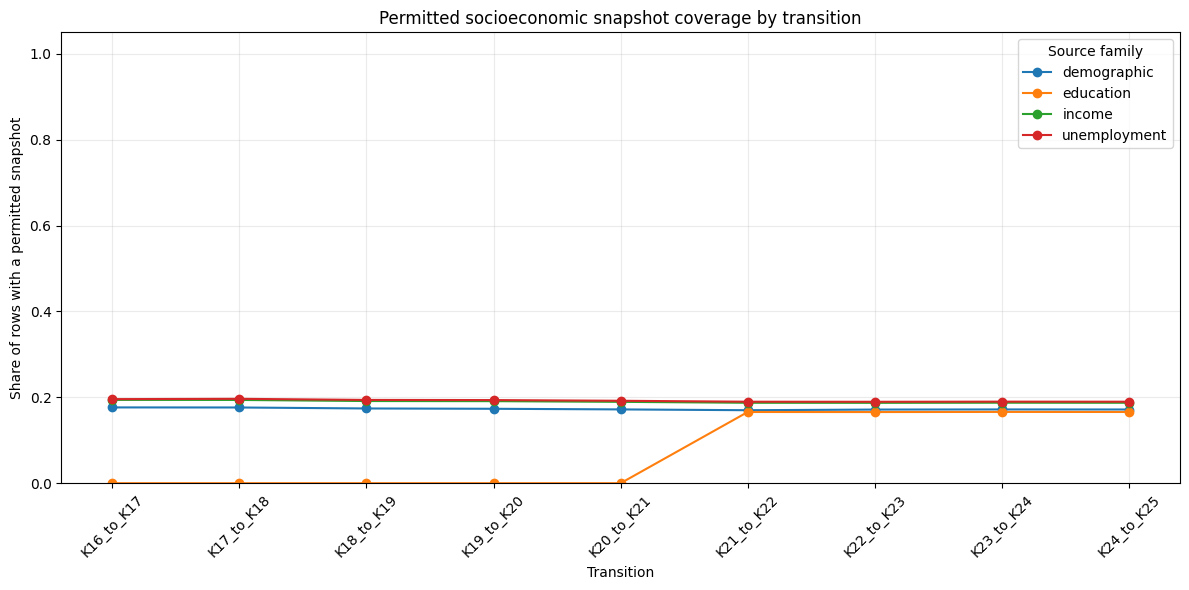

In [ ]:
SNAPSHOT_COVERAGE_FIGURE = (
    FIGURES_DIR
    / 'notebook_04_snapshot_coverage_by_transition.png'
)

snapshot_pivot = snapshot_coverage_by_transition.pivot(
    index='transition_id',
    columns='family',
    values='snapshot_coverage',
).reindex(EXPECTED_TRANSITIONS)

figure, axis = plt.subplots(figsize=(12, 6))

for family in snapshot_pivot.columns:
    axis.plot(
        snapshot_pivot.index,
        snapshot_pivot[family],
        marker='o',
        label=family,
    )

axis.set_title('Permitted socioeconomic snapshot coverage by transition')
axis.set_xlabel('Transition')
axis.set_ylabel('Share of rows with a permitted snapshot')
axis.set_ylim(0, 1.05)
axis.tick_params(axis='x', rotation=45)
axis.grid(alpha=0.25)
axis.legend(title='Source family')
figure.tight_layout()
figure.savefig(
    SNAPSHOT_COVERAGE_FIGURE,
    dpi=160,
    bbox_inches='tight',
)
plt.show()

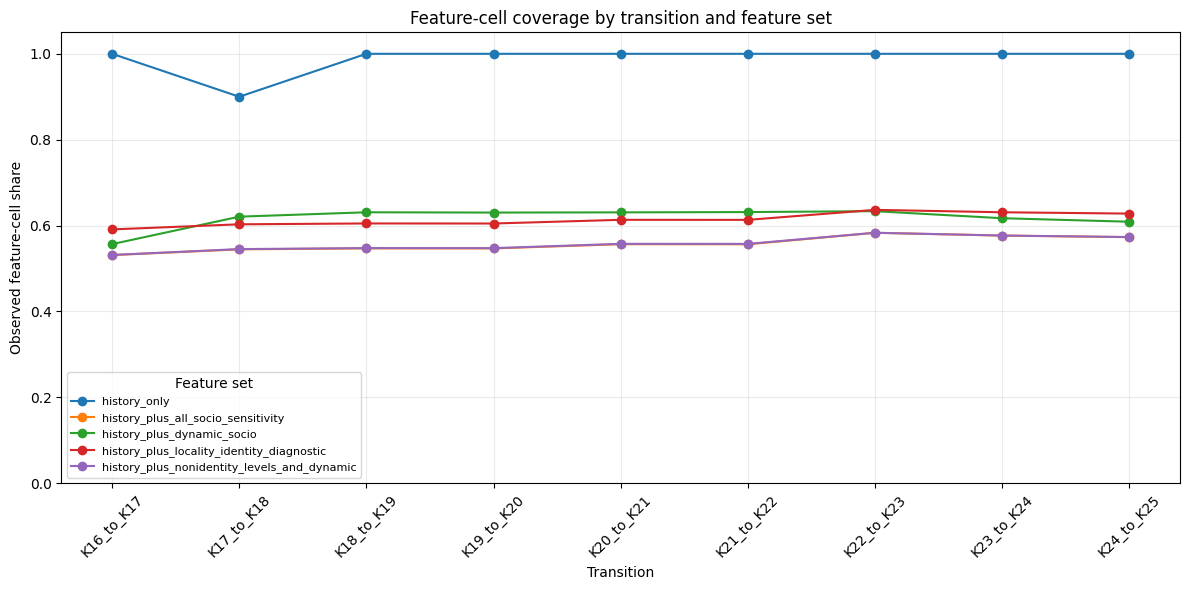

In [ ]:
FEATURE_SET_COVERAGE_FIGURE = (
    FIGURES_DIR
    / 'notebook_04_feature_set_coverage.png'
)

coverage_pivot = feature_coverage_by_transition.pivot(
    index='transition_id',
    columns='feature_set',
    values='cell_coverage',
).reindex(EXPECTED_TRANSITIONS)

figure, axis = plt.subplots(figsize=(12, 6))

for feature_set_name in coverage_pivot.columns:
    axis.plot(
        coverage_pivot.index,
        coverage_pivot[feature_set_name],
        marker='o',
        label=feature_set_name,
    )

axis.set_title('Feature-cell coverage by transition and feature set')
axis.set_xlabel('Transition')
axis.set_ylabel('Observed feature-cell share')
axis.set_ylim(0, 1.05)
axis.tick_params(axis='x', rotation=45)
axis.grid(alpha=0.25)
axis.legend(title='Feature set', fontsize=8)
figure.tight_layout()
figure.savefig(
    FEATURE_SET_COVERAGE_FIGURE,
    dpi=160,
    bbox_inches='tight',
)
plt.show()

## 16. Quality checks

In [ ]:
quality_rows = []


def record_check(check, passed, value, requirement):
    quality_rows.append({
        'check': check,
        'passed': bool(passed),
        'value': value,
        'requirement': requirement,
    })


record_check(
    'all_notebook_02_checks_passed',
    bool(nb02_quality['passed'].all()),
    int(nb02_quality['passed'].sum()),
    len(nb02_quality),
)

record_check(
    'all_notebook_03_checks_passed',
    bool(nb03_quality['passed'].all()),
    int(nb03_quality['passed'].sum()),
    len(nb03_quality),
)

record_check(
    'all_expected_socioeconomic_sources_exist',
    missing_source_files.empty,
    int(source_inventory['exists'].sum()),
    len(source_inventory),
)

record_check(
    'all_source_files_produced_numeric_features',
    bool(
        source_schema_audit['retained_numeric_features']
        .gt(0)
        .all()
    ),
    int(source_schema_audit['retained_numeric_features'].min()),
    '> 0 per time-varying source file',
)

record_check(
    'all_nine_transitions_present',
    actual_transitions == EXPECTED_TRANSITIONS,
    str(actual_transitions),
    str(EXPECTED_TRANSITIONS),
)

record_check(
    'only_k24_to_k25_is_locked',
    locked_transitions == [FINAL_TEST_TRANSITION],
    str(locked_transitions),
    str([FINAL_TEST_TRANSITION]),
)

record_check(
    'no_duplicate_model_rows',
    int(
        model_feature_table.duplicated(
            ['transition_id', 'locality_symbol']
        ).sum()
    ) == 0,
    int(
        model_feature_table.duplicated(
            ['transition_id', 'locality_symbol']
        ).sum()
    ),
    0,
)

maximum_timing_violations = int(
    snapshot_coverage_by_transition['timing_violations'].max()
)

record_check(
    'no_future_socioeconomic_snapshots',
    maximum_timing_violations == 0,
    maximum_timing_violations,
    0,
)

record_check(
    'dynamic_socio_features_exist',
    len(selected_change_features) > 0,
    len(selected_change_features),
    '> 0',
)

record_check(
    'all_feature_sets_are_nonempty',
    all(len(features) > 0 for features in FEATURE_SETS.values()),
    {name: len(features) for name, features in FEATURE_SETS.items()},
    'every set > 0',
)

forbidden_exact_features = {
    'locality_symbol',
    'locality_name',
    'row_id',
    'current_year',
    'current_election_number',
}

forbidden_pattern = re.compile(
    r'(^current_)|(^target_)|(^delta_)|prediction|error',
    flags=re.IGNORECASE,
)

leaky_manifest_features = sorted({
    feature
    for feature in feature_set_manifest['feature']
    if (
        feature in forbidden_exact_features
        or forbidden_pattern.search(feature)
    )
})

record_check(
    'no_target_or_current_outcome_features_in_manifest',
    len(leaky_manifest_features) == 0,
    leaky_manifest_features,
    '[]',
)

identifier_features_in_manifest = sorted(
    forbidden_exact_features
    & set(feature_set_manifest['feature'])
)

record_check(
    'locality_identifiers_are_not_model_features',
    len(identifier_features_in_manifest) == 0,
    identifier_features_in_manifest,
    '[]',
)

selection_development_rows = int(
    development_mask.sum()
)

record_check(
    'feature_screening_uses_development_rows_only',
    selection_development_rows
    == int(panel['data_role'].eq('development').sum()),
    selection_development_rows,
    int(panel['data_role'].eq('development').sum()),
)

final_test_rows = int(
    model_feature_table['transition_id']
    .eq(FINAL_TEST_TRANSITION)
    .sum()
)

record_check(
    'final_test_rows_are_retained_but_not_selected_on',
    final_test_rows > 0,
    final_test_rows,
    '> 0',
)

primary_dynamic_identity_features = sorted({
    feature
    for feature in FEATURE_SETS['history_plus_dynamic_socio']
    if (
        is_identity_proxy(feature)
        and not feature.startswith('missing__')
    )
})

record_check(
    'primary_dynamic_set_excludes_static_identity_features',
    not any(
        feature.startswith('locality_type__')
        or feature.endswith('__level')
        for feature in FEATURE_SETS['history_plus_dynamic_socio']
    ),
    primary_dynamic_identity_features,
    'no locality type or static level features',
)

notebook_04_quality_checks = pd.DataFrame(
    quality_rows
)

display(notebook_04_quality_checks)

failed_checks = notebook_04_quality_checks.loc[
    ~notebook_04_quality_checks['passed']
]

if not failed_checks.empty:
    raise RuntimeError(
        'Notebook 04 quality checks failed:\n'
        + failed_checks.to_string(index=False)
    )

print('All Notebook 04 quality checks passed.')

,check,passed,value,requirement
0,all_notebook_02_checks_passed,True,14,14
1,all_notebook_03_checks_passed,True,13,13
2,all_expected_socioeconomic_sources_exist,True,37,37
3,all_source_files_produced_numeric_features,True,3,> 0 per time-varying source file
4,all_nine_transitions_present,True,"['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K1...","['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K1..."
5,only_k24_to_k25_is_locked,True,['K24_to_K25'],['K24_to_K25']
6,no_duplicate_model_rows,True,0,0
7,no_future_socioeconomic_snapshots,True,0,0
8,dynamic_socio_features_exist,True,36,> 0
9,all_feature_sets_are_nonempty,True,"{'history_only': 10, 'history_plus_dynamic_soc...",every set > 0


All Notebook 04 quality checks passed.


## 17. Save all Notebook 04 outputs

In [ ]:
OUTPUT_PATHS = {
    'model_feature_table': (
        INTERIM_DIR / 'model_feature_table.csv'
    ),
    'source_inventory': (
        TABLES_DIR / 'notebook_04_source_inventory.csv'
    ),
    'source_schema_audit': (
        TABLES_DIR / 'notebook_04_source_schema_audit.csv'
    ),
    'source_availability': (
        TABLES_DIR / 'notebook_04_source_availability.csv'
    ),
    'feature_screening': (
        TABLES_DIR / 'notebook_04_feature_screening.csv'
    ),
    'feature_dictionary': (
        TABLES_DIR / 'notebook_04_feature_dictionary.csv'
    ),
    'feature_set_manifest': (
        TABLES_DIR / 'notebook_04_feature_set_manifest.csv'
    ),
    'feature_set_manifest_json': (
        SUMMARIES_DIR / 'notebook_04_feature_sets.json'
    ),
    'feature_coverage': (
        TABLES_DIR / 'notebook_04_feature_coverage_by_transition.csv'
    ),
    'snapshot_coverage': (
        TABLES_DIR / 'notebook_04_snapshot_coverage_by_transition.csv'
    ),
    'quality_checks': (
        TABLES_DIR / 'notebook_04_quality_checks.csv'
    ),
    'snapshot_coverage_figure': SNAPSHOT_COVERAGE_FIGURE,
    'feature_set_coverage_figure': FEATURE_SET_COVERAGE_FIGURE,
    'summary': (
        SUMMARIES_DIR / 'notebook_04_summary.json'
    ),
}

model_feature_table.to_csv(
    OUTPUT_PATHS['model_feature_table'],
    index=False,
    encoding='utf-8-sig',
)

source_inventory.to_csv(
    OUTPUT_PATHS['source_inventory'],
    index=False,
    encoding='utf-8-sig',
)

source_schema_audit.to_csv(
    OUTPUT_PATHS['source_schema_audit'],
    index=False,
    encoding='utf-8-sig',
)

family_source_availability.to_csv(
    OUTPUT_PATHS['source_availability'],
    index=False,
    encoding='utf-8-sig',
)

feature_screening.to_csv(
    OUTPUT_PATHS['feature_screening'],
    index=False,
    encoding='utf-8-sig',
)

feature_dictionary.to_csv(
    OUTPUT_PATHS['feature_dictionary'],
    index=False,
    encoding='utf-8-sig',
)

feature_set_manifest.to_csv(
    OUTPUT_PATHS['feature_set_manifest'],
    index=False,
    encoding='utf-8-sig',
)

feature_coverage_by_transition.to_csv(
    OUTPUT_PATHS['feature_coverage'],
    index=False,
    encoding='utf-8-sig',
)

snapshot_coverage_by_transition.to_csv(
    OUTPUT_PATHS['snapshot_coverage'],
    index=False,
    encoding='utf-8-sig',
)

notebook_04_quality_checks.to_csv(
    OUTPUT_PATHS['quality_checks'],
    index=False,
    encoding='utf-8-sig',
)

feature_set_json = {
    'selection_scope': 'development_rows_only',
    'selection_method': 'target_blind_coverage_and_variance',
    'primary_challenger': 'history_plus_dynamic_socio',
    'feature_set_roles': FEATURE_SET_ROLES,
    'feature_sets': FEATURE_SETS,
}

OUTPUT_PATHS['feature_set_manifest_json'].write_text(
    json.dumps(
        feature_set_json,
        ensure_ascii=False,
        indent=2,
    ),
    encoding='utf-8',
)

summary = {
    'notebook': '04_feature_engineering',
    'version': 'full_history_leakage_safe',
    'created_at_utc': time.strftime(
        '%Y-%m-%dT%H:%M:%SZ',
        time.gmtime(),
    ),
    'git_commit': GIT_COMMIT,
    'trusted_transition_input': str(
        PANEL_PATH.relative_to(REPO_ROOT)
    ),
    'notebook_03_best_baseline': best_baseline_name,
    'notebook_03_persistence_mean_fold_mae': float(
        nb03_summary['persistence_mean_fold_mae']
    ),
    'source_file_count': int(len(source_inventory)),
    'time_varying_source_file_count': int(
        source_inventory['source_year'].notna().sum()
    ),
    'static_source_file_count': int(
        source_inventory['source_year'].isna().sum()
    ),
    'feature_cutoff_policy': {
        'normal_transition': 'previous_election_year',
        'same_calendar_year_transition': 'previous_election_year_minus_one',
    },
    'development_transitions': DEVELOPMENT_TRANSITIONS,
    'final_test_transition': FINAL_TEST_TRANSITION,
    'final_test_locked': True,
    'feature_selection_uses_final_test': False,
    'feature_selection_uses_targets': False,
    'model_table_rows': int(len(model_feature_table)),
    'model_table_columns': int(model_feature_table.shape[1]),
    'manifest_feature_count': int(len(all_manifest_features)),
    'selected_history_feature_count': int(len(selected_history_features)),
    'selected_level_feature_count': int(len(selected_level_features)),
    'selected_dynamic_feature_count': int(len(selected_change_features)),
    'selected_recency_feature_count': int(len(selected_recency_features)),
    'selected_locality_type_diagnostic_count': int(
        len(selected_locality_type_features)
    ),
    'missing_indicator_count': int(len(missing_indicator_features)),
    'primary_challenger_feature_set': 'history_plus_dynamic_socio',
    'feature_set_counts': {
        name: len(features)
        for name, features in FEATURE_SETS.items()
    },
    'quality_checks_passed': bool(
        notebook_04_quality_checks['passed'].all()
    ),
    'outputs': {
        name: str(path.relative_to(REPO_ROOT))
        for name, path in OUTPUT_PATHS.items()
        if name != 'summary'
    },
}

OUTPUT_PATHS['summary'].write_text(
    json.dumps(
        summary,
        ensure_ascii=False,
        indent=2,
    ),
    encoding='utf-8',
)

output_audit = pd.DataFrame([
    {
        'output': name,
        'relative_path': str(path.relative_to(REPO_ROOT)),
        'exists': path.exists(),
        'size_bytes': (
            path.stat().st_size
            if path.exists()
            else 0
        ),
    }
    for name, path in OUTPUT_PATHS.items()
])

display(output_audit)

bad_outputs = output_audit.loc[
    ~output_audit['exists']
    | output_audit['size_bytes'].le(0)
]

if not bad_outputs.empty:
    raise RuntimeError(
        'Missing or empty Notebook 04 outputs:\n'
        + bad_outputs.to_string(index=False)
    )

print('All Notebook 04 outputs were saved successfully.')

,output,relative_path,exists,size_bytes
0,model_feature_table,data/interim/model_feature_table.csv,True,20719143
1,source_inventory,reports/tables/notebook_04_source_inventory.csv,True,2699
2,source_schema_audit,reports/tables/notebook_04_source_schema_audit...,True,4487
3,source_availability,reports/tables/notebook_04_source_availability...,True,1029
4,feature_screening,reports/tables/notebook_04_feature_screening.csv,True,108206
5,feature_dictionary,reports/tables/notebook_04_feature_dictionary.csv,True,183830
6,feature_set_manifest,reports/tables/notebook_04_feature_set_manifes...,True,256918
7,feature_set_manifest_json,reports/summaries/notebook_04_feature_sets.json,True,137998
8,feature_coverage,reports/tables/notebook_04_feature_coverage_by...,True,3356
9,snapshot_coverage,reports/tables/notebook_04_snapshot_coverage_b...,True,2122


All Notebook 04 outputs were saved successfully.


## 18. Download all Notebook 04 outputs

In [ ]:
# Independent download cell. It uses explicit paths and does not depend on
# the OUTPUT_PATHS variable surviving in memory.
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from google.colab import files

repo_root = Path('/content/Election_Bloc_Prediction_Project_nb04')
zip_path = Path('/content/notebook_04_outputs.zip')

output_files = [
    repo_root / 'data/interim/model_feature_table.csv',
    repo_root / 'reports/tables/notebook_04_source_inventory.csv',
    repo_root / 'reports/tables/notebook_04_source_schema_audit.csv',
    repo_root / 'reports/tables/notebook_04_source_availability.csv',
    repo_root / 'reports/tables/notebook_04_feature_screening.csv',
    repo_root / 'reports/tables/notebook_04_feature_dictionary.csv',
    repo_root / 'reports/tables/notebook_04_feature_set_manifest.csv',
    repo_root / 'reports/tables/notebook_04_feature_coverage_by_transition.csv',
    repo_root / 'reports/tables/notebook_04_snapshot_coverage_by_transition.csv',
    repo_root / 'reports/tables/notebook_04_quality_checks.csv',
    repo_root / 'reports/figures/notebook_04_snapshot_coverage_by_transition.png',
    repo_root / 'reports/figures/notebook_04_feature_set_coverage.png',
    repo_root / 'reports/summaries/notebook_04_feature_sets.json',
    repo_root / 'reports/summaries/notebook_04_summary.json',
]

missing_files = [
    str(path.relative_to(repo_root))
    for path in output_files
    if not path.exists() or path.stat().st_size <= 0
]

if missing_files:
    raise RuntimeError(
        'Run the Notebook 04 save cell first. Missing outputs:\n- '
        + '\n- '.join(missing_files)
    )

if zip_path.exists():
    zip_path.unlink()

with ZipFile(
    zip_path,
    mode='w',
    compression=ZIP_DEFLATED,
) as zip_file:
    for path in output_files:
        zip_file.write(
            path,
            arcname=str(path.relative_to(repo_root)),
        )

print('ZIP created:', zip_path)
print('ZIP size:', zip_path.stat().st_size, 'bytes')
print('Files included:', len(output_files))

files.download(str(zip_path))

ZIP created: /content/notebook_04_outputs.zip
ZIP size: 3542617 bytes
Files included: 14


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Completion criteria

A successful run ends with:

```text
Earlier-notebook validation passed.
Transition panel validation passed.
All Notebook 04 quality checks passed.
All Notebook 04 outputs were saved successfully.
ZIP created: /content/notebook_04_outputs.zip
```

Notebook 05 should use:

- `data/interim/model_feature_table.csv`
- `reports/summaries/notebook_04_feature_sets.json`

The primary challenger to persistence is:

```text
history_plus_dynamic_socio
```